In [10]:
#Python v3.11.8
#Import necessary packages

import os
import sys

import pandas as pd
import numpy as np

sys.path.append('functions')

from greatbrowser import great_analysis

from gene_analysis_functions import get_cistrome, get_pos, insig_nan
from pseudoinverse_functions import pinv_dropmin, quality_filter, trait_cluster

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
'''
Establich cwd, get relevant data, and perform basic formatting
'''

#set directory, import data, drop undefined
os.chdir('/Users/samanderson/Desktop/pellegrini_lab_research/raw_data')
data = pd.read_excel('methylation_phenotype_encoded.xlsx', index_col=0) #mm39
data = data.dropna()

#referring to the point in the data where methylation and phenotype data diverge
sep=55

#seperate trait and methylation data
trait_data = data[:sep]
meth_data = data[sep:]

print(f'{trait_data.shape[0]} traits')

55 traits


In [12]:
#filter trait data to minimize colinearity
filter = 0.70
f_trait_data = quality_filter(trait_data, filter)

print(f'\n{f_trait_data.shape[0]} traits')


initializing: M12_poststress_GLU

M10_poststress_GLU corr: 0.6719015152375838
M8_poststress_GLU corr: 0.6090336912254721
M6_poststress_GLU corr: 0.5802400592602832
M4_poststress_GLU corr: 0.5311748134680883
M2_poststress_GLU corr: 0.3228813190001512
w4_stress_GLU corr: 0.3560799023117119
Baseline_GLU corr: 0.4321213022396831
M12_poststress_FFM_g corr: 0.016038987694264484
M10_poststress_FFM_g corr: 0.1032664053853798
M8_poststress_FFM_g corr: 0.13022424239458588
M6_poststress_FFM_g corr: 0.14497224377218185
M4_poststress_FFM_g corr: 0.13864898633105477
M2_poststress_FFM_g corr: 0.040837730206165726
w4_stress_FFM_g corr: 0.010086677800758868
Baseline_FFM_g corr: 0.04630001033314697
M12_poststress_FM_g corr: 0.15170584503159446
M10_poststress_FM_g corr: 0.3359654636524691
M8_poststress_FM_g corr: 0.30474076619102525
M6_poststress_FM_g corr: 0.5008174335569449
M4_poststress_FM_g corr: 0.5065860565548835
M2_poststress_FM_g corr: 0.5062768154108793
w4_stress_FM_g corr: 0.42022147758972955


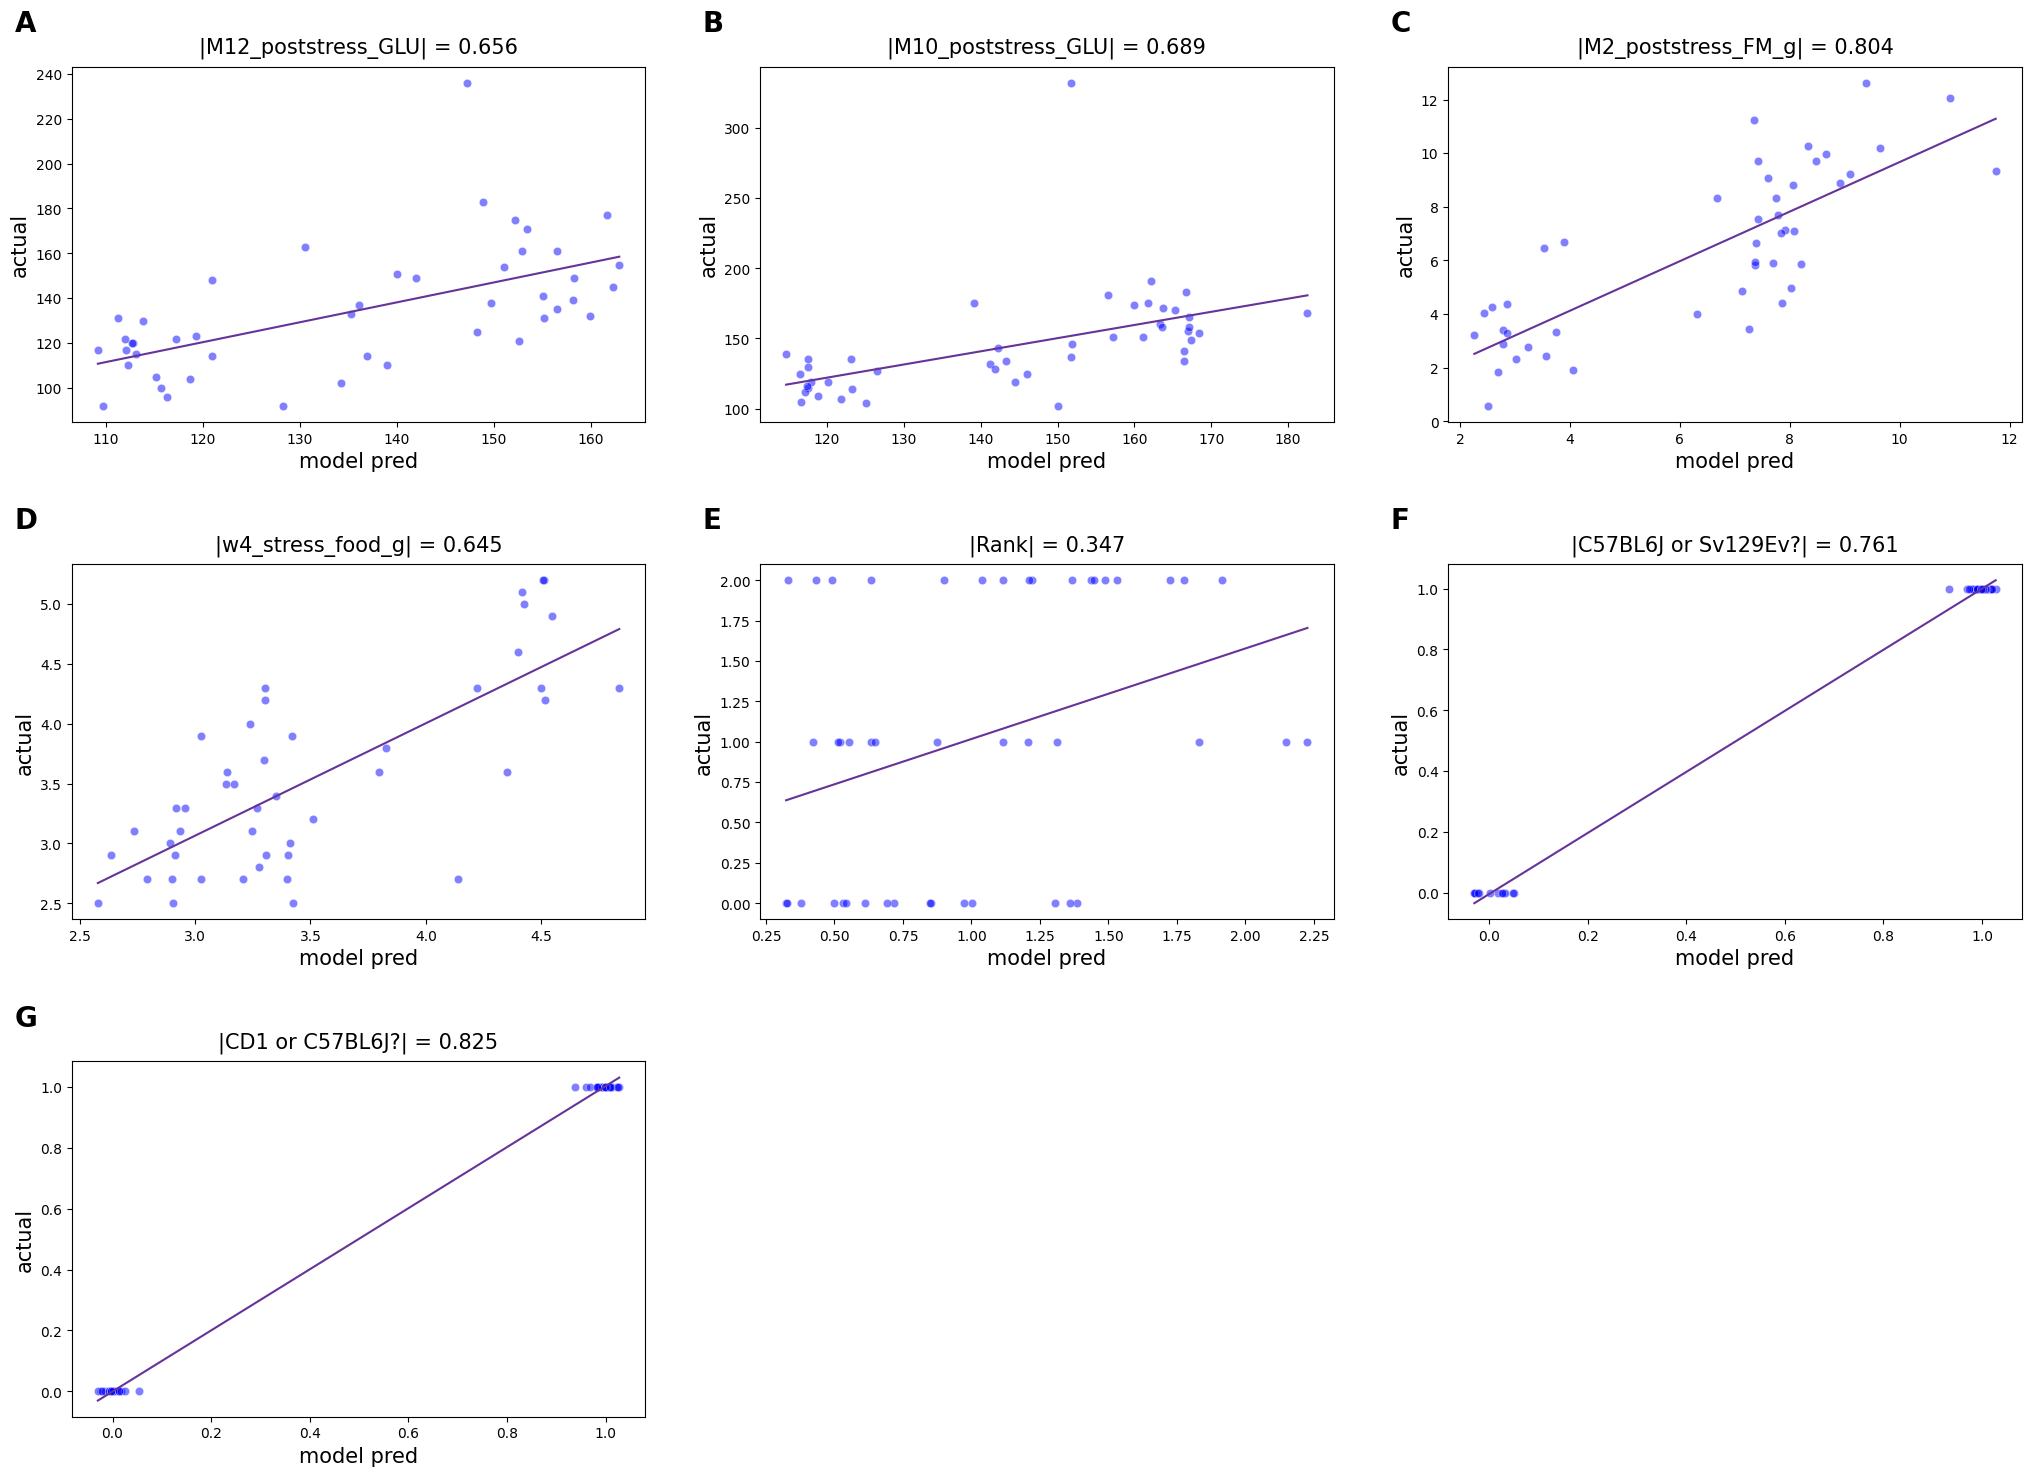

In [19]:
#generate pseudoinversion plots
thresh = 0.6
meth_filter_thresh = 0.5
pinv_dropmin(f_trait_data, meth_data, thresh, 
             find_meth=False, to_filter_meth=True, 
             meth_filter_thresh=meth_filter_thresh);

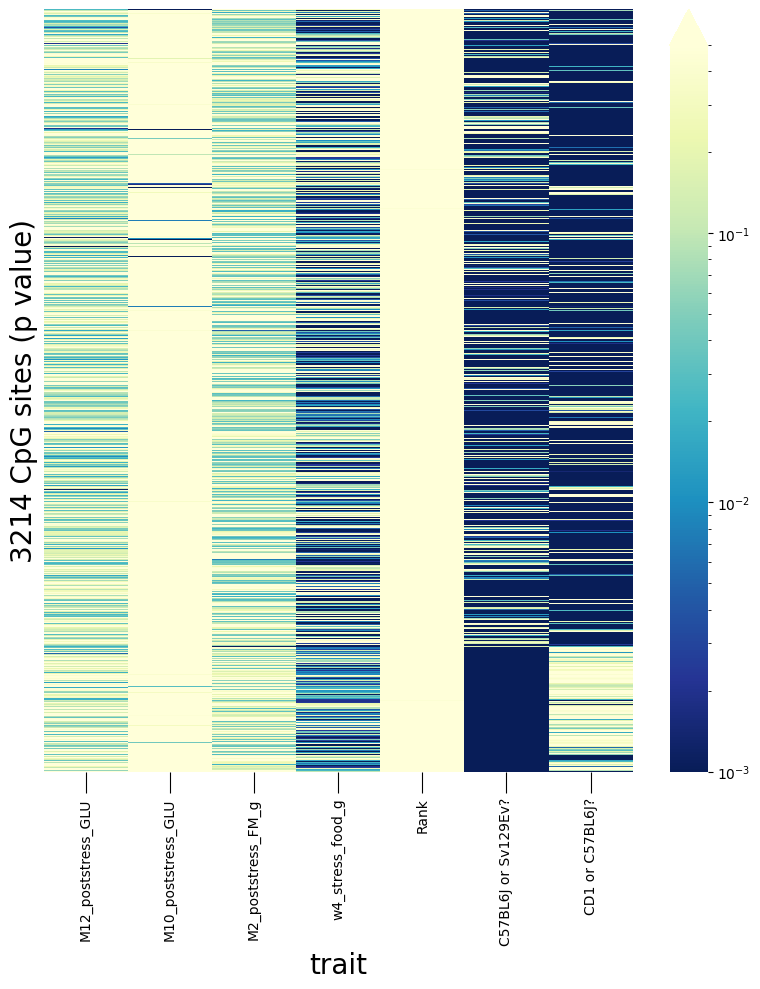

In [14]:
#generate heatmap of probe/trait multivar association p values
thresh = 0.6
meth_filter_thresh = 0.5
is_filtered = True
trait_vals, trait_pvals, trait_coef = pinv_dropmin(f_trait_data, meth_data, thresh, 
                                                   find_meth=True, plot_results=True, 
                                                   to_filter_meth=is_filtered, meth_filter_thresh=meth_filter_thresh);

In [15]:
#identify most significant probes
mm39_data = pd.read_excel('mm39_formatted_manifest.xlsx', index_col=0)
probe_df = get_pos(trait_vals, mm39_data);

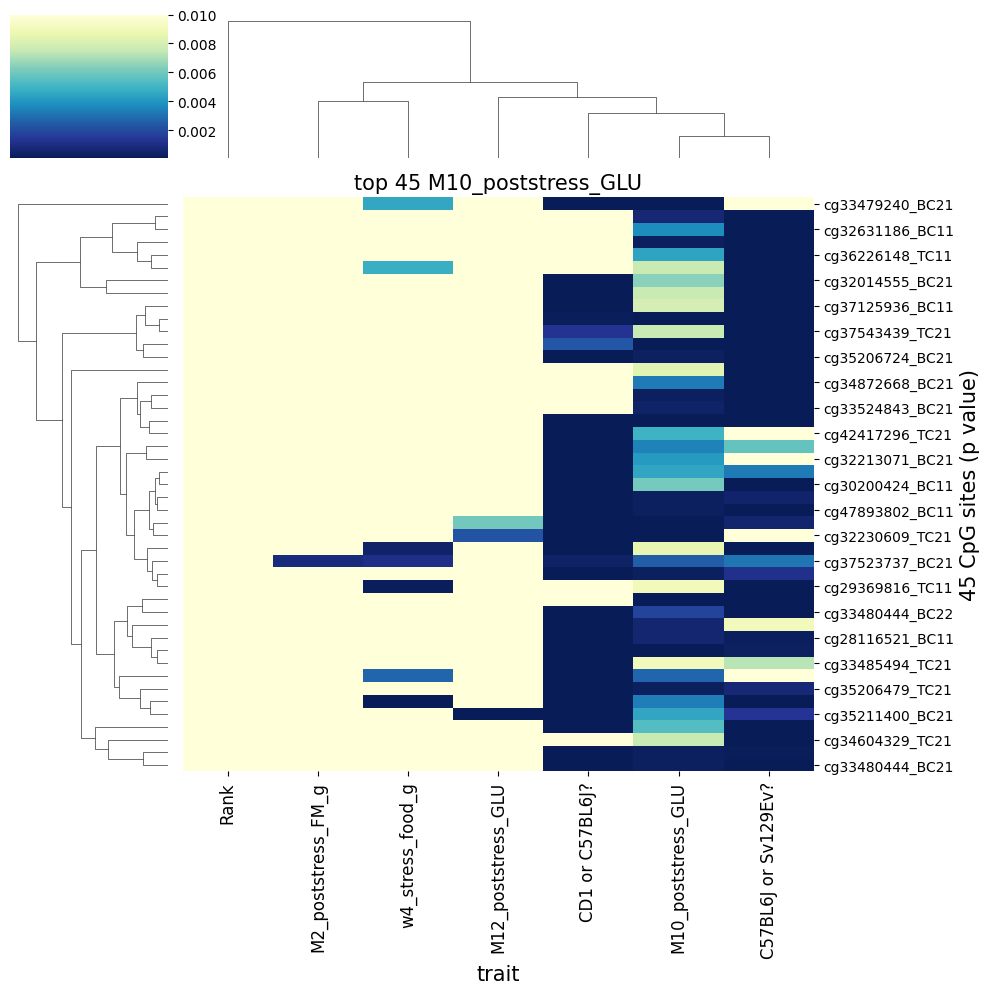

In [16]:
#generate a clustermap of significant probes for selected trait
sig_df = insig_nan(probe_df)
trait = 'M10_poststress_GLU_pval'

temp = sig_df[trait].values
temp = temp[~np.isnan(temp)]
n_probes = len(temp)

trait_cluster(trait_pvals, trait[:-5], n_probes);

In [17]:
#find gene associations of probes via GREAT

temp = probe_df.reset_index()
temp = great_analysis(temp, get='genes', df_chr ='chr_mm10', df_start='pos_mm10', df_end='end_mm10', df_index='index')

temp = temp.set_index('index')
trait_vals['associated_genes'] = temp['associated_genes']

if is_filtered:
    trait_vals.to_excel('pseudoinverse_probes_filtered.xlsx')
else:
    trait_vals.to_excel('pseudoinverse_probes_unfiltered.xlsx')

trait_vals

,M12_poststress_GLU_pval,M12_poststress_GLU_coef,M10_poststress_GLU_pval,M10_poststress_GLU_coef,M2_poststress_FM_g_pval,M2_poststress_FM_g_coef,w4_stress_food_g_pval,w4_stress_food_g_coef,Rank_pval,Rank_coef,...,C57BL6J or Sv129Ev?_coef,CD1 or C57BL6J?_pval,CD1 or C57BL6J?_coef,chr_mm39,pos_mm39,end_mm39,chr_mm10,pos_mm10,end_mm10,associated_genes
index,,,,,,,,,,,,,,,,,,,,,
cg28113426_BC11,0.787708,-0.000047,0.999699,-0.000100,0.668641,0.000982,0.103152,0.009125,0.936874,-0.006018,...,0.000548,2.320521e-34,0.658940,chr10,3802852,3802854,chr10,3852852.0,3852854.0,"Mthfd1l (-120,278), Plekhg1 (+112,489)"
cg28116521_BC11,0.048040,0.001197,0.000577,-0.002046,0.659531,0.003467,0.253040,0.021870,0.954608,0.010958,...,0.153297,4.720625e-14,0.553085,chr10,4080228,4080230,chr10,4130228.0,4130230.0,"Akap12 (-136,151), Mthfd1l (+157,098)"
cg28117414_TC21,0.025817,0.001809,0.000091,-0.002977,0.720152,0.003518,0.338129,0.022692,0.936874,0.026716,...,0.185056,1.191008e-15,0.772848,chr10,4163086,4163088,chr10,4213086.0,4213088.0,"Akap12 (-53,293), Mthfd1l (+239,956)"
cg28133420_BC21,0.206678,-0.000816,0.544356,-0.000954,0.158000,0.011688,0.106830,0.034970,0.979571,-0.004627,...,0.831722,6.871347e-02,0.104130,chr10,5993540,5993542,chr10,6043540.0,6043542.0,"Rgs17 (-121,141), Gm10945 (+718,220)"
cg28139216_TC21,0.009337,0.001194,0.412989,0.000585,0.981033,-0.000143,0.392741,0.010521,0.979571,-0.001615,...,-0.068422,3.211165e-05,0.142249,chr10,7002802,7002804,chr10,7052802.0,7052804.0,"Ipcef1 (-73,092), Cnksr3 (+159,434)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg48343126_BC21,0.061635,0.001008,0.999699,0.000397,0.994831,0.000056,0.023568,0.039632,0.961010,0.005088,...,0.459760,8.545935e-02,-0.079096,chrY,90730534,90730536,chrY,90719265.0,90719267.0,"Gm21996 (-973,734), Erdr1 (-65,472)"
cg48343211_TC11,0.313025,0.000595,0.473040,0.000913,0.286809,0.008080,0.035820,0.041461,0.985080,0.001283,...,0.493651,9.405323e-02,-0.087256,chrY,90737336,90737338,chrY,90726067.0,90726069.0,"Gm21996 (-980,536), Erdr1 (-58,670)"
cg48343225_BC11,0.782435,0.000154,0.999699,0.000133,0.495968,0.004791,0.006830,0.049115,0.954609,-0.008348,...,0.516767,9.800450e-01,0.001314,chrY,90738474,90738476,chrY,90727205.0,90727207.0,"Gm21996 (-981,674), Erdr1 (-57,532)"


In [18]:
%matplotlib inline

#drop insignificant values
cistrome_df = insig_nan(trait_vals)

#this is trial and error, unfortunately 
fig_w = 2800
fig_h = 3000

#generate cistrome plots by trait for significant probes
get_cistrome(cistrome_df, fig_w, fig_h)

KeyboardInterrupt: 